<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/Entornos_Complejos/Deep_Q_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Q-Learning

*Description*: En este notebook se desarrolla la implementación del método de **Deep Q-Learning**, y se emplea sobre el entorno Mountain Car de Gymnasium.


    Autores: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín

    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
            
    Date: 2026/02/25


El entorno **Mountain Car** presenta un espacio de estados continuo, ya que la posición y la velocidad del vehículo toman valores reales dentro de un intervalo. Esto implica que no es posible representar la función de valor o la función Q mediante una tabla finita sin realizar una discretización previa. Sin embargo, discretizar el espacio continuo puede provocar una pérdida significativa de información o un crecimiento exponencial del número de estados si se desea mantener precisión, lo que hace que los métodos tabulares resulten ineficientes o directamente inviables.

Por este motivo, es necesario emplear **métodos aproximados**, como *Deep Q-Learning*, que utilizan redes neuronales para aproximar la función Q. Este enfoque permite generalizar entre estados similares y manejar espacios de alta dimensionalidad o continuos de forma eficiente, haciendo posible el aprendizaje en entornos como Mountain Car donde los métodos clásicos tabulares no escalan adecuadamente.

Empezamos instalando e importando las librerías necesarias. También definimos los dispositivos donde se ejecutará el notebook y la semilla que vamos a usar para asegurar reproducibilidad.

In [1]:
%%capture
!pip install 'gym[box2d]==0.20.0'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import torch
import gc
import os

In [3]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


gc.collect()              # Ejecuta el recolector de basura de Python
if torch.cuda.is_available():
    torch.cuda.empty_cache()   # Limpia la caché de la GPU


SEED = 123

# NumPy
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Python
os.environ["PYTHONHASHSEED"] = str(SEED)

# Fijar la semilla en PyTorch
torch.manual_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed(SEED)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

Usando dispositivo: cuda


## Definición de la Neural Network

Lo primero que vamos a hacer es definir la red neuronal que usaremos para calcular la función $Q(s, a)$ usando Deep Q-Learning. La arquitectura que proponemos es sencilla, constando de tres capas totalmente conectadas (fully connected), con funciones de activación ReLU entre ellas (con hidden size 128), y una capa de salida que devuelve un vector de valores $Q$ para cada acción posible en el estado dado. Esta configuración permite que la red aprenda una aproximación de la función de valor $Q(s, a)$ de manera no lineal, lo cual es crucial para entornos con dinámicas complejas.


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DQN_Network(nn.Module):
    """
    Red neuronal sencilla para Deep Q-Learning.
    """

    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(DQN_Network, self).__init__()

        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

Para que el agente de Deep Q-Learning pueda aprender de manera estable, es fundamental almacenar sus experiencias en una **memoria de repetición (Replay Memory)**. Esta memoria guarda las transiciones observadas durante la interacción con el entorno y permite muestrear de forma aleatoria mini-batches para el entrenamiento, rompiendo la correlación temporal entre experiencias consecutivas y mejorando la estabilidad del aprendizaje.

La clase `ReplayMemory` implementa esta funcionalidad de manera sencilla. Se inicializa con un tamaño máximo, y cada nueva transición `(estado, acción, recompensa, siguiente_estado, terminado)` se añade de forma circular cuando se alcanza la capacidad máxima. El método `sample_batch` devuelve un lote aleatorio de experiencias convertidas a tensores de PyTorch, listas para ser utilizadas en la actualización de la red neuronal. Esto permite que el agente aprenda de un conjunto más diverso de experiencias y evita que se sobreajuste a transiciones recientes.


In [5]:
import random
import numpy as np
import torch

class ReplayMemory:
    """
    Memoria de experiencias para DQN.
    Almacena transiciones y permite muestreo aleatorio.
    """

    def __init__(self, max_size):
        self.memory = []
        self.max_size = max_size
        self.position = 0

    def store(self, state, action, reward, next_state, done):
        """
        Guarda una transición en memoria.
        Si se alcanza la capacidad máxima, sobrescribe en modo circular.
        """
        transition = (state, action, reward, next_state, done)

        if len(self.memory) < self.max_size:
            self.memory.append(transition)
        else:
            self.memory[self.position] = transition

        self.position = (self.position + 1) % self.max_size

    def sample_batch(self, batch_size):
        """
        Devuelve un batch aleatorio de experiencias como tensores.
        """
        batch = random.sample(self.memory, batch_size)

        states = []
        actions = []
        rewards = []
        next_states = []
        dones = []

        for s, a, r, ns, d in batch:
            states.append(s)
            actions.append(a)
            rewards.append(r)
            next_states.append(ns)
            dones.append(d)

        states = torch.tensor(np.array(states), dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.long).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.memory)

## Agente

Para implementar un agente de **Deep Q-Learning** más estable y eficiente, definimos la clase `DQN_Agent`, que integra varias mejoras modernas sobre el DQN clásico:

- **Double DQN**: Utilizamos dos redes neuronales, la **red principal** y la **red objetivo**, para reducir la sobreestimación de los valores $Q$. La red principal selecciona la acción óptima para el siguiente estado, mientras que la red objetivo evalúa el valor de esa acción. Esta separación permite que el agente aprenda políticas más precisas y estables.  
- **Replay Buffer**: Almacena transiciones en una memoria de repetición, de modo que el entrenamiento se realiza con mini-batches aleatorios, rompiendo la correlación temporal entre experiencias consecutivas.  
- **Epsilon-greedy con decay automático**: Inicialmente, el agente explora mucho (epsilon alto) y, progresivamente, reduce la exploración siguiendo un decaimiento exponencial, hasta un valor mínimo.  
- **Gradient clipping y optimización con Adam**: Se recortan los gradientes para evitar explosiones durante el entrenamiento, asegurando estabilidad en la actualización de pesos.  
- **Actualización periódica de la red objetivo**: La red objetivo se sincroniza con la red principal cada cierto número de pasos, controlando la velocidad de propagación de las actualizaciones y evitando inestabilidad.



In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class DQN_Agent:
    """
    Agente Double DQN con:
    - Replay Buffer
    - Target network con actualización periódica
    - Epsilon-greedy con decay automático
    - Gradient clipping
    """

    def __init__(self,
                 env,
                 hidden_dim=128,
                 lr=1e-3,
                 gamma=0.99,
                 epsilon=1.0,
                 epsilon_min=0.05,
                 epsilon_decay=0.995,
                 buffer_size=10000,
                 batch_size=64,
                 target_update_freq=1000,
                 max_steps_episode=200,
                 clip_grad=1.0,
                 device=None):

        self.env = env
        self.device = device if device else torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.state_dim = env.observation_space.shape[0]
        self.action_dim = env.action_space.n

        # Hiperparámetros
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.max_steps_episode = max_steps_episode
        self.clip_grad = clip_grad

        self.steps = 0

        # Redes
        self.qnet = DQN_Network(self.state_dim, self.action_dim, hidden_dim).to(self.device)
        self.qnet_target = DQN_Network(self.state_dim, self.action_dim, hidden_dim).to(self.device)

        self.qnet_target.load_state_dict(self.qnet.state_dict())
        self.qnet_target.eval()

        self.optimizer = optim.Adam(self.qnet.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

        # Replay buffer (usa tu ExperienceMemory reescrito)
        self.replay_buffer = ReplayMemory(buffer_size)

    def select_action(self, state):
        """
        Política epsilon-greedy.
        """
        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()

        state = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)

        with torch.no_grad():
            q_values = self.qnet(state)

        return torch.argmax(q_values, dim=1).item()

    def greedy_action(self, state):
        """
        Acción puramente greedy (sin exploración).
        """
        state = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)

        with torch.no_grad():
            q_values = self.qnet(state)

        return torch.argmax(q_values, dim=1).item()

    def update(self):
        """
        Entrenamiento usando Double DQN.
        """

        if len(self.replay_buffer) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = \
            self.replay_buffer.sample_batch(self.batch_size)

        states = states.to(self.device)
        actions = actions.to(self.device)
        rewards = rewards.to(self.device)
        next_states = next_states.to(self.device)
        dones = dones.to(self.device)

        # Q(s,a)
        q_values = self.qnet(states)
        qsa = torch.gather(q_values, 1, actions)

        # Double DQN
        with torch.no_grad():
            next_actions = torch.argmax(self.qnet(next_states), dim=1, keepdim=True)
            next_q_target = self.qnet_target(next_states)
            qsa_next = torch.gather(next_q_target, 1, next_actions)

            q_target = rewards + (1 - dones) * self.gamma * qsa_next

        loss = self.loss_fn(qsa, q_target)

        self.optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(self.qnet.parameters(), self.clip_grad)

        self.optimizer.step()

        # Actualización periódica del target
        if self.steps % self.target_update_freq == 0:
            self.qnet_target.load_state_dict(self.qnet.state_dict())

        self.steps += 1

        return loss.item()

    def update_epsilon(self):
        """
        Decaimiento de epsilon.
        """
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def save_model(self, path):
        torch.save(self.qnet.state_dict(), path)

    def load_model(self, path):
        self.qnet.load_state_dict(torch.load(path, map_location=self.device))

## Esquema de aprendizaje

El entrenamiento del agente de Deep Q-Learning sigue la misma filosofía general que en el Q-Learning clásico: el agente interactúa con el entorno episodio a episodio, acumulando recompensas y aprendiendo de cada transición. Sin embargo, en lugar de actualizar directamente una tabla $Q$, se ajustan los **pesos de la red neuronal** que aproxima la función $Q(s, a)$.

La función `train_dqn` ejecuta este proceso:

1. **Inicialización del episodio**: Se reinicia el entorno y se preparan variables para almacenar recompensas, pérdidas y longitud del episodio.  
2. **Selección de acción y transición**: Para cada paso del episodio, el estado se normaliza y se elige una acción según la política epsilon-greedy del agente. Después, se observa la transición `(estado, acción, recompensa, siguiente_estado, done)` y se almacena en el **replay buffer**.  
3. **Actualización de la red**: Cada paso llama al método `update` del agente, que calcula la pérdida Double DQN y ajusta los pesos de la red principal. Se aplica **gradient clipping** y, periódicamente, se sincroniza la red objetivo.  
4. **Decaimiento de epsilon**: Al final de cada episodio, el valor de epsilon se reduce progresivamente para favorecer la explotación sobre la exploración.  
5. **Registro de métricas**: Se guardan la recompensa total, la longitud del episodio y la pérdida media para análisis posteriores.

Un aspecto que consideramos importante comentar es que antes de alimentar los estados a la red neuronal, es importante **normalizarlos** para que todos los valores estén en rangos comparables. La función `normalize_state` ajusta las posiciones y velocidades del entorno a un intervalo [0, 1], considerando los límites conocidos de cada variable. Esto ayuda a que la red neuronal aprenda de manera más estable y eficiente, evitando que magnitudes distintas en la entrada generen gradientes desproporcionados o dificulten la convergencia durante el entrenamiento.

In [7]:
def normalize_state(state):
    pos_min, pos_max = -1.2, 0.6
    vel_min, vel_max = -0.07, 0.07
    pos = (state[0] - pos_min) / (pos_max - pos_min)
    vel = (state[1] - vel_min) / (vel_max - vel_min)
    return np.array([pos, vel])


In [8]:
from tqdm import tqdm
import numpy as np

def train_dqn(agent, num_episodes, seed=None):

    rewards_per_episode = []
    episode_lengths = []
    episode_losses = []

    display_step = max(1, num_episodes // 10)

    for episode in tqdm(range(num_episodes)):

        state, _ = agent.env.reset(seed=seed)
        done = False
        total_reward = 0
        step_count = 0
        losses = []

        while not done and step_count < agent.max_steps_episode:

            state = normalize_state(state)
            action = agent.select_action(state)
            next_state, reward, done, _, _ = agent.env.step(action)

            next_state = normalize_state(next_state)

            agent.replay_buffer.store(state, action, reward, next_state, done)

            loss = agent.update()
            if loss is not None:
                losses.append(loss)

            state = next_state
            total_reward += reward
            step_count += 1

        # Decaimiento de epsilon al final del episodio
        agent.update_epsilon()

        mean_loss = np.mean(losses) if losses else 0.0

        rewards_per_episode.append(total_reward)
        episode_lengths.append(step_count)
        episode_losses.append(mean_loss)

        if (episode + 1) % display_step == 0:
            print(f"Episode {episode+1}/{num_episodes} | "
                  f"Reward: {total_reward:.2f} | "
                  f"Length: {step_count} | "
                  f"Epsilon: {agent.epsilon:.4f} | "
                  f"Loss: {mean_loss:.5f}")

    return rewards_per_episode, episode_lengths, episode_losses

## Funciones auxiliares

Ahora vamos a definir una serie de funciones auxiliares que nos van a servir para mostrar resultados y realizar el análisis.

La primera función que definimos la usaremos una vez entrenado el agente, de forma que podamos evaluar el aprendizaje llevado a cabo.

In [9]:
def run_episode_greedy(agent, max_steps=200):
    """
    Ejecuta un episodio usando la política greedy y captura los fotogramas.

    Parámetros:
      - agent: Agente DQN con método greedy_action() y env.
      - max_steps (int): Número máximo de pasos a ejecutar en el episodio.

    Retorna:
      - list: Lista de fotogramas (imágenes) capturados durante el episodio.
    """

    frames = []

    # Reiniciar el entorno
    state, _ = agent.env.reset()
    done = False

    for _ in range(max_steps):
        # Capturar fotograma actual
        frame = agent.env.render()
        frames.append(frame)

        # Selección greedy de acción
        action = agent.greedy_action(state)

        # Ejecutar acción
        next_state, reward, done, truncated, info = agent.env.step(action)
        state = next_state

        # Si el episodio termina, capturar fotograma final y salir
        if done or truncated:
            frames.append(agent.env.render())
            break

    return frames

Las siguiente funciones mostrarán las gráficas de aprendizaje y longitud de los episodios una vez realizado el aprendizaje de los agentes.

La longitud del episodio es un medidor de rendimiento interesante porque no solo indica si el agente alcanza la meta, sino también **cómo de eficiente es la política aprendida**. En entornos donde existe una ruta óptima, la convergencia hacia un número estable y bajo de pasos suele reflejar que el agente ha aprendido un comportamiento estructurado y cercano al óptimo.

Además, esta métrica permite interpretar mejor los resultados: episodios muy cortos pueden indicar caídas tempranas en estados terminales negativos, mientras que episodios largos pueden reflejar exploración excesiva o movimientos erráticos. Por ello, la longitud del episodio complementa a la recompensa promedio y ayuda a entender no solo si el agente aprende, sino **cómo está aprendiendo**.

In [15]:

import matplotlib.pyplot as plt

def compute_running_mean(series, window):
    """
    Calcula un suavizado tipo media deslizante sobre una serie temporal.
    """
    kernel = np.full(window, 1.0 / window)
    return np.convolve(series, kernel, mode="valid")

def display_training_curve(values, plot_title, window=100):
    """
    Muestra un gráfico de evolución de un valor (como reward o loss) por episodio,
    incluyendo la media móvil para resaltar tendencias.

    Parámetros:
        values (list o array): Valores a graficar.
        plot_title (str): Título del gráfico.
        window (int): Ventana para la media móvil.
    """
    num_points = len(values)
    episodes = range(num_points)  # eje x

    plt.figure(figsize=(8, 4))
    plt.plot(episodes, values, marker='o', linestyle='-', color='tab:blue', alpha=0.5, label='Valor por episodio')

    # Media móvil
    if window > 1 and num_points >= window:
        running_mean = compute_running_mean(values, window)
        plt.plot(range(window-1, num_points), running_mean, color='tab:red', linewidth=2, label=f'Media móvil ({window})')

    plt.title(plot_title)
    plt.xlabel("Episodio")
    plt.ylabel("Valor")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()



def draw_episode_length_trend(length_history):
    """
    Visualiza la evolución del tamaño de los episodios junto con
    una versión suavizada para observar la tendencia global.
    """

    fig, ax = plt.subplots(figsize=(10, 4))

    # Señal original (transparente)
    ax.plot(length_history, alpha=0.25, color="forestgreen")

    # Tendencia suavizada
    smoothing_window = 100
    smoothed = compute_running_mean(length_history, smoothing_window)

    ax.plot(
        np.arange(len(smoothed)),
        smoothed,
        linewidth=2,
        color="darkgreen",
        label="Media suavizada"
    )

    ax.set_title("Evolución del tamaño de episodio")
    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()


def draw_episode_length_comparison(length_dict):
    """
    Compara la evolución de longitud de episodio entre varios experimentos.
    """

    palette = ["darkred", "navy", "darkgreen", "purple", "orange"]

    fig, ax = plt.subplots(figsize=(10, 4))

    smoothing_window = 100

    for idx, (label, values) in enumerate(length_dict.items()):

        color = palette[idx % len(palette)]

        # Señal original
        ax.plot(values, alpha=0.2, color=color)

        # Tendencia suavizada
        smoothed = compute_running_mean(values, smoothing_window)
        ax.plot(
            np.arange(len(smoothed)),
            smoothed,
            linewidth=2,
            color=color,
            label=label
        )

    ax.set_title("Comparativa de longitudes de episodio")
    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()

Las siguientes funciones servirán para visualizar los resultados con imágenes y gifs del comportamiento del agente.

In [11]:
import seaborn as sns
import imageio
import base64
from IPython.display import HTML
import matplotlib.pyplot as plt



def create_gif_from_frames(frame_list, output_path="frozenlake_agent.gif"):
    """
    Genera un GIF animado a partir de una lista de imágenes.

    Parámetros:
      - frame_list (list): Lista de frames capturados del entorno.
      - output_path (str): Nombre del archivo GIF resultante.

    Retorna:
      - str: Ruta del GIF creado.
    """
    with imageio.get_writer(output_path, mode="I") as gif_writer:
        for frame in frame_list:
            gif_writer.append_data(frame)
    return output_path


def show_gif_in_notebook(gif_file_path):
    """
    Inserta un GIF en una celda de Jupyter Notebook o Colab.

    Parámetros:
      - gif_file_path (str): Ruta del archivo GIF.

    Retorna:
      - HTML: Objeto HTML para mostrar el GIF.
    """
    with open(gif_file_path, "rb") as f:
        gif_bytes = f.read()

    b64_str = base64.b64encode(gif_bytes).decode("utf-8")
    return HTML(f'<img src="data:image/gif;base64,{b64_str}" />')

## Entorno Mountain Car

A continuación, creamos el entorno "Mountain Car" de Gymnasium con el que trabajaremos.

In [10]:
env = gym.make("MountainCar-v0", render_mode="rgb_array")
# Fijamos la semilla
env.reset(seed=SEED)

(array([-0.46352962,  0.        ], dtype=float32), {})

Finalmente, ejecutamos el **entrenamiento completo del agente**. En este bloque se inicializa el agente `DQN_Agent` con los hiperparámetros seleccionados, incluyendo la dimensión de la red, tasa de aprendizaje, gamma, valores de epsilon y tamaño del buffer. Luego se llama a la función `train_dqn` para entrenar durante `n_episodes` episodios, registrando recompensas, longitudes de episodio y pérdidas promedio.

Los hiperparámetros elegidos para el agente (`hidden_dim=128`, `lr=1e-3`, `gamma=0.99`, `epsilon` inicial alto con decaimiento, `buffer_size=10000`, `batch_size=64` y `target_update_freq=1000`) corresponden a **valores típicos en la literatura de Deep Q-Learning**, equilibrando exploración, capacidad de la red y estabilidad del entrenamiento. Estos valores permiten que la red aprenda de manera eficiente sin requerir ajustes excesivos en entornos estándar como Mountain Car o CartPole. Cabe señalar que, para la selección y ajuste inicial de estos parámetros, se ha contado con **asistencia de herramientas de IA generativa**, que han sugerido combinaciones razonables basadas en prácticas comunes en Deep Reinforcement Learning.

Al finalizar el entrenamiento, se guarda el modelo entrenado mediante `save_model`, de manera que pueda reutilizarse o evaluarse posteriormente. Además, se imprimen métricas resumidas, como el número total de pasos realizados y la recompensa media de los últimos 100 episodios, permitiendo evaluar de manera rápida el desempeño del agente y su capacidad de convergencia.


In [13]:
n_episodes = 2000  # menos para pruebas rápidas

agent = DQN_Agent(
    env,
    hidden_dim=128,
    lr=1e-3,
    gamma=0.99,
    epsilon=1.0,          # empezamos más exploratorio
    epsilon_min=0.05,
    epsilon_decay=0.995,
    buffer_size=10000,
    batch_size=64,
    target_update_freq=1000,
    max_steps_episode=200,
    clip_grad=1.0
)

rewards_per_episode, episode_lengths, episode_losses = train_dqn(agent, n_episodes, seed=SEED)

# Guardar modelo final
agent.save_model("modelo_dqn.pth")

print(f"Entrenamiento finalizado. Pasos totales: {agent.steps}")
print(f"Reward medio últimos 100 episodios: {np.mean(rewards_per_episode[-100:]):.2f}")



 10%|█         | 200/2000 [01:48<15:58,  1.88it/s]

Episode 200/2000 | Reward: -200.00 | Length: 200 | Epsilon: 0.3670 | Loss: 0.60826


 20%|██        | 400/2000 [03:41<14:39,  1.82it/s]

Episode 400/2000 | Reward: -200.00 | Length: 200 | Epsilon: 0.1347 | Loss: 0.08355


 30%|███       | 600/2000 [05:47<16:28,  1.42it/s]

...

Episode 1600/2000 | Reward: -200.00 | Length: 200 | Epsilon: 0.0500 | Loss: 9628.03515


 90%|█████████ | 1800/2000 [17:32<01:50,  1.81it/s]

Episode 1800/2000 | Reward: -200.00 | Length: 200 | Epsilon: 0.0500 | Loss: 24494.20903


100%|██████████| 2000/2000 [19:26<00:00,  1.71it/s]

Episode 2000/2000 | Reward: -200.00 | Length: 200 | Epsilon: 0.0500 | Loss: 10445.16298
Entrenamiento finalizado. Pasos totales: 399937
Reward medio últimos 100 episodios: -200.00


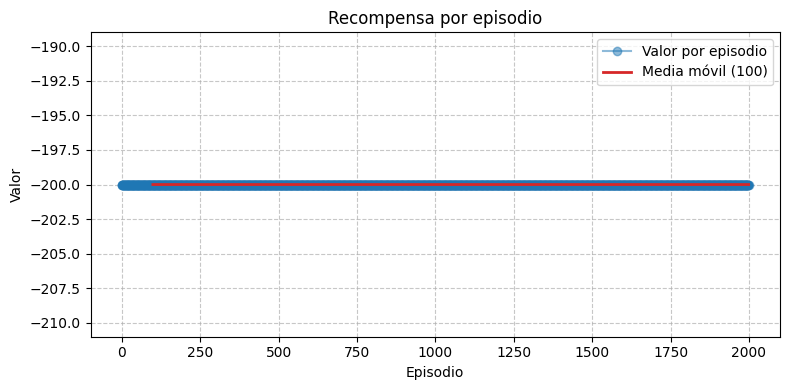

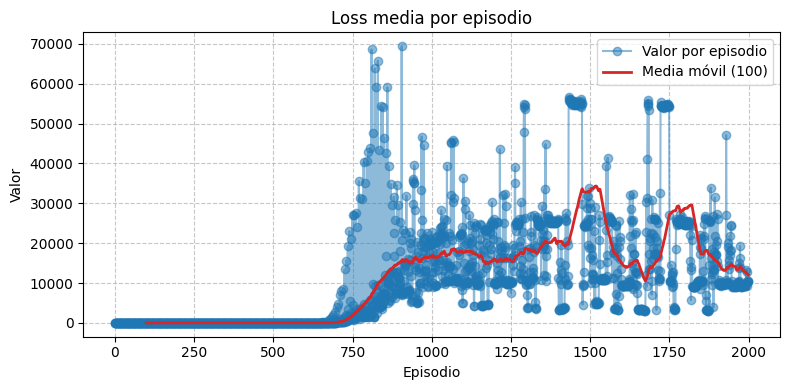

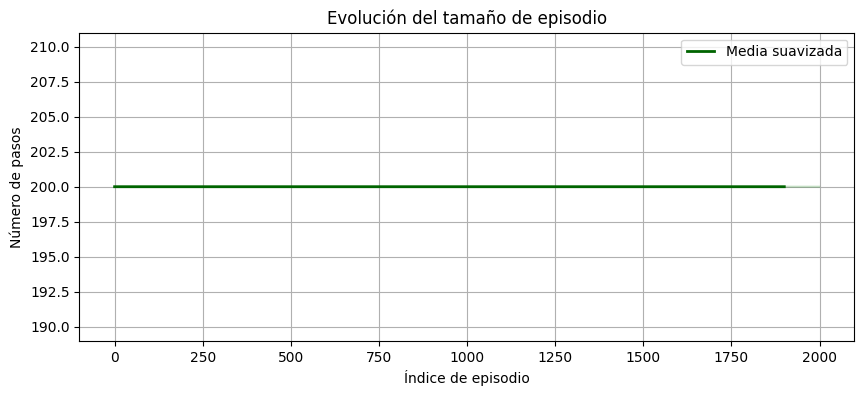

In [16]:
display_training_curve(rewards_per_episode, "Recompensa por episodio")
display_training_curve(episode_losses, "Loss media por episodio")
draw_episode_length_trend(episode_lengths)

Como se puede observar, los resultados obtenidos son nefastos. No hay ningún indicio de aprendizaje, obteniendo siempre una recompensa de -200, indicando que el coche llega al límite de episodios sin lograr llegar a la cima objetivo.

En el entorno **Mountain Car**, la recompensa original es siempre `-1` por paso hasta alcanzar la meta, lo que provoca que, durante episodios largos, el total acumulado sea siempre negativo (por ejemplo, alrededor de `-200` si el agente tarda mucho en llegar). Este esquema de recompensas dificulta que el agente aprenda, ya que la señal de aprendizaje es muy poco informativa y no diferencia estados parciales que sean mejores que otros. El problema surge porque el agente solo recibe información positiva al final del episodio, haciendo que la red neuronal tenga dificultades para estimar qué acciones intermedias acercan realmente a la meta.

Para mejorar el aprendizaje, se nos ocurrió que se podría modificar las recompensas del entorno, de forma que se beneficien posiciones más cercanas al objetivo y velocidades más altas. Para que el agente aprenda rápido, pensamos en el coche como un sistema físico que necesita Energía Mecánica. En lugar de dejar que el agente deambule al azar, hemos modificado la recompensa para que valore la energía potencial (premiando que el coche esté lo más alto posible en la pendiente) y, sobre todo, la energía cinética. Al multiplicar la velocidad absoluta por un factor de 10, el agente recibe un estímulo positivo cada vez que gana inercia. Esto es fundamental en Mountain Car, porque le enseña al modelo que alejarse de la meta para coger "carrerilla" no es un error, sino una estrategia necesaria para acumular la energía suficiente y vencer la gravedad. Sin este enfoque basado en la física, la red neuronal tardaría miles de episodios más en descubrir por pura suerte que necesita balancearse para llegar arriba.

Por ello, introducimos un **reward shaping** que modifica la señal de recompensa para que sea más informativa:

1. **Recompensa por posición**: se premia avanzar hacia la meta, escalando la posición del coche. Esto guía al agente a progresar horizontalmente.  
2. **Recompensa por velocidad**: se premia el valor absoluto de la velocidad, incentivando que el agente "balancee" el coche para ganar impulso.  
3. **Bonus por alcanzar la meta**: se añade un valor extra cuando la posición final supera el umbral de 0.5, reforzando el éxito.

Con este enfoque, el agente recibe señales parciales de progreso en cada paso, lo que acelera la convergencia y permite aprender estrategias de balanceo más efectivas. Es importante aclarar que este sistema de Reward Shaping es una herramienta que usamos exclusivamente para "guiar" el aprendizaje de la red neuronal durante el entrenamiento. Sin embargo, a la hora de evaluar el éxito real y generar las gráficas de rendimiento, seguimos utilizando la recompensa original del entorno (-1 por cada paso). De esta forma, aunque el agente esté motivado internamente por sus bonos de energía y velocidad, lo que nosotros visualizamos es su capacidad real para reducir el tiempo total de ejecución y llegar a la meta lo más rápido posible.

Por último, cabe mencionar que la implementación de esta técnica ha sido apoyada mediante **asistencia de IA generativa**, que sugirió cómo combinar recompensas de posición, velocidad y logro para mejorar la señal de aprendizaje en entornos continuos como Mountain Car.


In [17]:
from tqdm import tqdm
import numpy as np

def train_dqn_reward_shaped(agent, num_episodes, seed=None):

    rewards_per_episode = []
    episode_lengths = []
    episode_losses = []

    display_step = max(1, num_episodes // 10)

    for episode in tqdm(range(num_episodes)):

        state, _ = agent.env.reset(seed=seed)
        done = False
        total_reward = 0
        step_count = 0
        losses = []

        while not done and step_count < agent.max_steps_episode:

            norm_state = normalize_state(state)


            action = agent.select_action(norm_state)
            next_state, reward, done, _, _ = agent.env.step(action)
            norm_next_state = normalize_state(next_state)

            # El reward original es siempre -1. Vamos a mejorarlo:

            # Recompensa por posición (cuanto más a la derecha, mejor)
            # El objetivo es llegar a 0.5. Escalamos la posición para que sume.
            shaping_reward = reward + (next_state[0] + 0.5)

            # B) Recompensa por velocidad (premiar la energía cinética)
            # Esto ayuda a que el agente aprenda a "balancearse" para ganar impulso.
            shaping_reward += 10 * abs(next_state[1])

            # C) Bonus por éxito
            if next_state[0] >= 0.5:
                shaping_reward += 50
            # -------------------------------------------

            # 4. Guardar en buffer y actualizar
            agent.replay_buffer.store(norm_state, action, shaping_reward, norm_next_state, done)

            loss = agent.update()
            if loss is not None:
                losses.append(loss)

            state = next_state
            total_reward += reward # Aquí solemos guardar el reward original para trackear progreso real
            step_count += 1

        # Decaimiento de epsilon al final del episodio
        agent.update_epsilon()

        mean_loss = np.mean(losses) if losses else 0.0

        rewards_per_episode.append(total_reward)
        episode_lengths.append(step_count)
        episode_losses.append(mean_loss)

        if (episode + 1) % display_step == 0:
            print(f"Episode {episode+1}/{num_episodes} | "
                  f"Reward: {total_reward:.2f} | "
                  f"Length: {step_count} | "
                  f"Epsilon: {agent.epsilon:.4f} | "
                  f"Loss: {mean_loss:.5f}")

    return rewards_per_episode, episode_lengths, episode_losses

Con todo esto, volvemos a ejecutar el entrenamiento de un agente con los mismos parámetros, pero esta vez usando la función de entrenamiento con reward shaping.

In [18]:
n_episodes = 2000  # menos para pruebas rápidas

agent2 = DQN_Agent(
    env,
    hidden_dim=128,
    lr=1e-3,
    gamma=0.99,
    epsilon=1.0,          # empezamos más exploratorio
    epsilon_min=0.05,
    epsilon_decay=0.995,
    buffer_size=10000,
    batch_size=64,
    target_update_freq=1000,
    max_steps_episode=200,
    clip_grad=1.0
)

rewards_per_episode2, episode_lengths2, episode_losses2 = train_dqn_reward_shaped(agent2, n_episodes, seed=SEED)

# Guardar modelo final
agent.save_model("modelo_dqn2.pth")

print(f"Entrenamiento finalizado. Pasos totales: {agent2.steps}")
print(f"Reward medio últimos 100 episodios: {np.mean(rewards_per_episode2[-100:]):.2f}")

 10%|█         | 200/2000 [01:51<16:55,  1.77it/s]

Episode 200/2000 | Reward: -200.00 | Length: 200 | Epsilon: 0.3670 | Loss: 0.01119


 20%|██        | 400/2000 [03:29<10:53,  2.45it/s]

Episode 400/2000 | Reward: -157.00 | Length: 157 | Epsilon: 0.1347 | Loss: 0.44503


 30%|███       | 600/2000 [04:53<09:48,  2.38it/s]

...

Episode 1600/2000 | Reward: -140.00 | Length: 140 | Epsilon: 0.0500 | Loss: 0.94660


 90%|█████████ | 1800/2000 [13:28<01:05,  3.07it/s]

Episode 1800/2000 | Reward: -122.00 | Length: 122 | Epsilon: 0.0500 | Loss: 0.33162


100%|██████████| 2000/2000 [14:43<00:00,  2.26it/s]

Episode 2000/2000 | Reward: -177.00 | Length: 177 | Epsilon: 0.0500 | Loss: 0.44883
Entrenamiento finalizado. Pasos totales: 308486
Reward medio últimos 100 episodios: -140.93


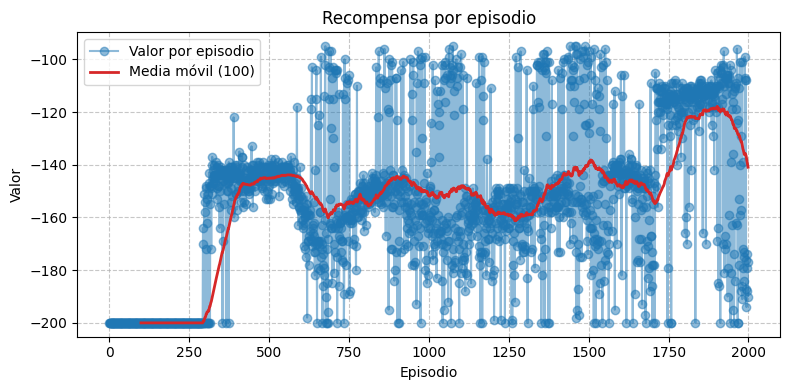

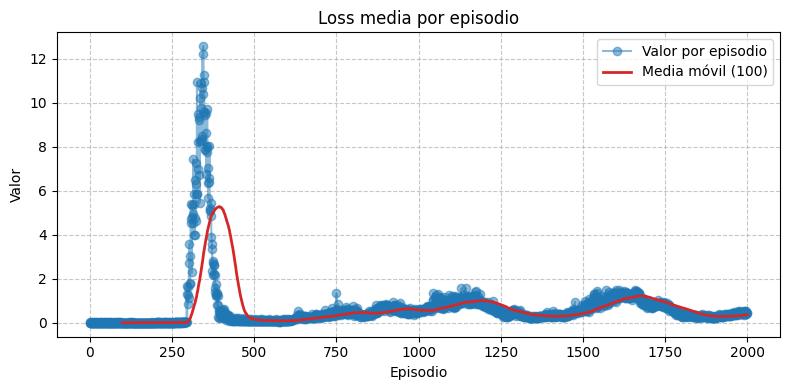

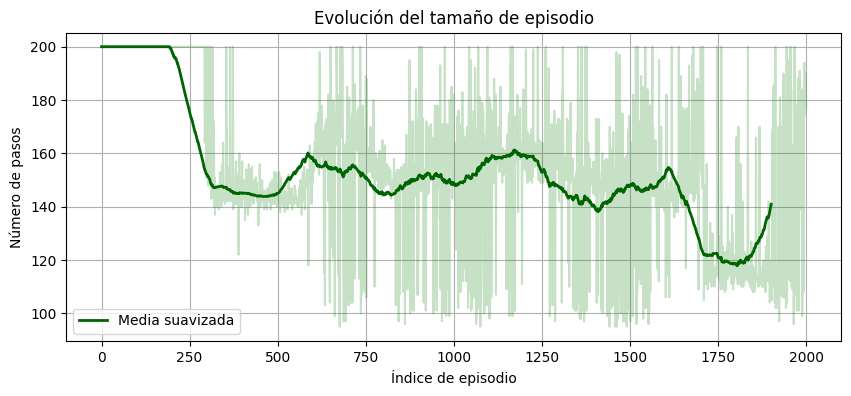

In [19]:
display_training_curve(rewards_per_episode2, "Recompensa por episodio")
display_training_curve(episode_losses2, "Loss media por episodio")
draw_episode_length_trend(episode_lengths2)

Tras implementar las mejoras en la función de recompensa y la normalización de estados, los resultados obtenidos muestran un cambio significativo en el comportamiento del agente. La gráfica de **Recompensa por Episodio** evidencia que el agente ha comenzado a comprender cómo interactuar con el entorno.

Durante los primeros 300 episodios, el coche permanecía atrapado en el fondo del valle, como se refleja en la línea plana cercana a -200. Gracias al reward shaping, cuando el agente alcanzó la meta por primera vez, incluso por azar, la red neuronal pudo identificar qué acciones le permitían ganar altura y velocidad. A partir de ese momento, la media móvil (línea roja) muestra un ascenso pronunciado, indicando que el agente empieza a aprender de manera consistente.

Por tanto, a diferencia de los intentos previos, el agente ya no vuelve a quedarse permanentemente en -200. Aunque hay algunos episodios donde tarda más en alcanzar la meta, la tendencia general es positiva. La media móvil se estabiliza en torno a -140 / -120, lo que indica que el coche completa el circuito de manera bastante consistente.

Con esto se demuestra que nuestro nuevo enfoque para la recompensa es sumamente útil, ya que permite mejorar drásticamente la capacidad de aprendizaje del modelo. Al sustituir el castigo constante de -1 por una señal que incentiva la energía mecánica (combinando altura y velocidad), hemos logrado que el agente deje de dar "palos de ciego" y empiece a optimizar su trayectoria de forma deliberada. La gráfica refleja claramente que, al priorizar tanto la energía potencial para ganar altura como la energía cinética para generar inercia mediante el balanceo, el agente no solo descubre cómo llegar a la meta, sino que además lo hace de manera mucho más eficiente y estable, superando el estancamiento inicial que presentaba el algoritmo estándar.

Por último, cabe destacar que aunque el entrenamiento se guía con recompensas extra por altura y velocidad, la gráfica muestra el **reward original de Gym** (-1 por paso). Esto confirma que el agente no está simplemente acumulando “puntos artificiales”, sino que realmente ha aprendido a llegar a la meta en menos pasos que antes.

## Posibles mejoras y líneas de Investigación Futuras

Aunque los resultados obtenidos tras aplicar el Reward Shaping y la arquitectura Double DQN son satisfactorios, el campo del Aprendizaje por Refuerzo ofrece múltiples vías para seguir optimizando este agente. A continuación, se plantean algunas líneas de investigación que podrían mejorar la eficiencia y la robustez del modelo:

1. **Refinamiento de la Función de Recompensa**

A pesar de que el enfoque basado en energía mecánica funcionó, se podrían explorar otras técnicas de shaping más avanzadas, como el Potential-based Reward Shaping (PBRS). Esta técnica garantiza matemáticamente que el agente no se desvíe del objetivo original (evitando el reward hacking). Probar con funciones no lineales para la velocidad o penalizaciones por acciones bruscas podría suavizar aún más la trayectoria del coche.

2. **Optimización de Hiperparámetros del Entrenamiento**

El éxito del entrenamiento depende críticamente de la relación entre la exploración y la explotación. Por tanto, podríamos investigar diferentes formas de aplicar el decaimiento de Epsilon u otros learning rates, entre otras opciones.

3. **Arquitecturas de Red Neuronal y Algoritmos**

En este experimento hemos aplicado una red neuronal bastante sencilla, con solo tres capas. Aunque aumentar la complejidad de la red a ciegas no tiene sentido, sobre todo debido al aumento de necesidad de cómputo que esto conlleva, se podría intentar mejorar la red usada para obtener mejores resultados. Esto implicaría cambiar el tipo de capas y/o funciones de activación, tamaños de las mismas o número de capas.